In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Is Set")
else:
    raise ValueError("API Key Is Not Set")

API Key Is Set


In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model = "openai/gpt-oss-120b")

In [3]:
from typing import TypedDict, List, Annotated
from operator import add

class graph_schema(TypedDict):
    messages_manual : List
    # messages_auto : Annotated[List,add]
    

In [10]:
from langchain_core.messages import AIMessage, HumanMessage

def create_post(state:graph_schema) -> graph_schema:
    
    #convert the pydantic model to a dictionary
    
    messages_manual = state['messages_manual']
    
    response_manual = llm.invoke("What Is The Silicon Valley of india").content
    response_manual_ai = AIMessage(content = response_manual)
    
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    return state

def curate_post(state: graph_schema) -> graph_schema:
    
    messages_manual = state['messages_manual']
    
    response_manual = llm.invoke("Give In genz tone").content
    response_manual_ai = AIMessage(response_manual)
    
    state['messages_manual'] = messages_manual + [response_manual_ai]
    
    return state
    

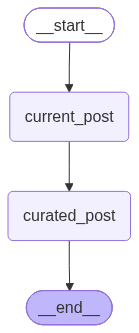

In [11]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("current_post",create_post)
graph.add_node("curated_post",curate_post)

graph.add_edge(START, "current_post")
graph.add_edge("current_post","curated_post")
graph.add_edge("curated_post",END)

final_graph = graph.compile()
final_graph

In [ ]:
final_graph.invoke({"messages_manual":[HumanMessage(content = "The Silicon Valley of india")]})

{'messages_manual': [HumanMessage(content='The Silicon Valley of india', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Bangalore (Bengaluru) – the “Silicon Valley of India”**\n\nWhen people refer to the “Silicon Valley of India,” they are almost always talking about **Bangalore (officially Bengaluru)**, the capital city of the Indian state of Karnataka.  \n\n### Why Bangalore earned that nickname\n\n| Factor | Details |\n|--------|---------|\n| **Concentration of IT & Software Companies** | Home to the Indian headquarters of global giants such as **Microsoft, Google, Amazon, Apple, IBM, Intel, Cisco, and Oracle**. It also hosts thousands of Indian IT firms like **Infosys, Wipro, Tata Consultancy Services (TCS), and HCL Technologies**. |\n| **Startup Ecosystem** | Over **10,000 tech startups** operate in the city, spanning fintech, AI, healthtech, edtech, e‑commerce, and more. Notable “unicorns” (valued >\u202f$1\u202fbn) that began here include **Flipkart, Swiggy,